# Using Qrisp circuits with Topologiq

In [1]:
import os
import sys

repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Uncomment line below to enable interactive 3D visuals, but bear in mind it will ask you to approve a download.
# %matplotlib widget

This notebook offers an example of how to use ***Topologiq*** to perform algorithmic lattice surgery on a Qrisp circuit.

## Qrisp

Let's start by creating a nice circuit using Qrisp. 

We won't be using a famous circuit. Instead, we will focus on using different kinds of gates to see Topologiq in action.

In [2]:
from qrisp import QuantumVariable, h, z, s, t, measure

# Give a catchy name to circuit
circuit_name = "qrisp_single"

# Create a Quantum Variable of 1 single qubit
qrisp_circuit = QuantumVariable(1)

# Add gates
h(qrisp_circuit[0])
z(qrisp_circuit[0])
s(qrisp_circuit[0])
t(qrisp_circuit[0])

# Visualise
print(qrisp_circuit.qs)

QuantumCircuit:
---------------
                 ┌───┐┌───┐┌───┐┌───┐
qrisp_circuit.0: ┤ H ├┤ Z ├┤ S ├┤ T ├
                 └───┘└───┘└───┘└───┘
Live QuantumVariables:
----------------------
QuantumVariable qrisp_circuit


## Qrisp - PyZX

The next step is to bring the circuit into Topologiq's general workflow and convert it into PyZX. 

There's a hard and an easy way to do this.
- Hard way: convert the Qrisp circuit to QASM using native Qrisp methods, then import to PyZX using native PyZX methods.
- Easy way: convert Qrisp circuit to Qiskit, then use Topologiq's circuit and ZX graph manager to achieve the conversion. 

We'll go the easy way here.

In [3]:
import pyzx as zx
from topologiq.input.circuit_manager import CircuitManager
from topologiq.input.zx_manager import ZXGraphManager

# -> Qiskit
qc = qrisp_circuit.qs.to_qiskit()

# -> QASM
circuit_manager = CircuitManager()
qasm_str = circuit_manager.add_qiskit_circuit(qc, key="qrisp_circuit")

# QASM -> ZX manager
zx_graph_manager = ZXGraphManager()
augmented_zx_graph = zx_graph_manager.add_graph_from_qasm(
    qasm_str=qasm_str, graph_key=circuit_name
)
zx.draw(augmented_zx_graph.zx_graph, labels=True)

## Topologiq

Time for ***Topologiq*** to do its thing. 

This part is also super easy. We just call the `.get_blockgraph` method of the `augmented_zx_graph` we created above. That will return a `BlockGraphManager` object, which is Topologiq's primary object for realised blockgraphs.

> One could also create the `BlockGraphManager` manually and give it the PyZX graph one wants to perform lattice surgery on. But that take a couple more lines of codes and it's not necessary here.


In [4]:
# Run Topologiq on full (unreduced graph)
bgraph_manager = augmented_zx_graph.get_blockgraph()


SUCCESS! Habemus BlockGraph. Volume: 16. Duration: 0.07s



## Output

That's it. You can now visualise the built BlockGraph.

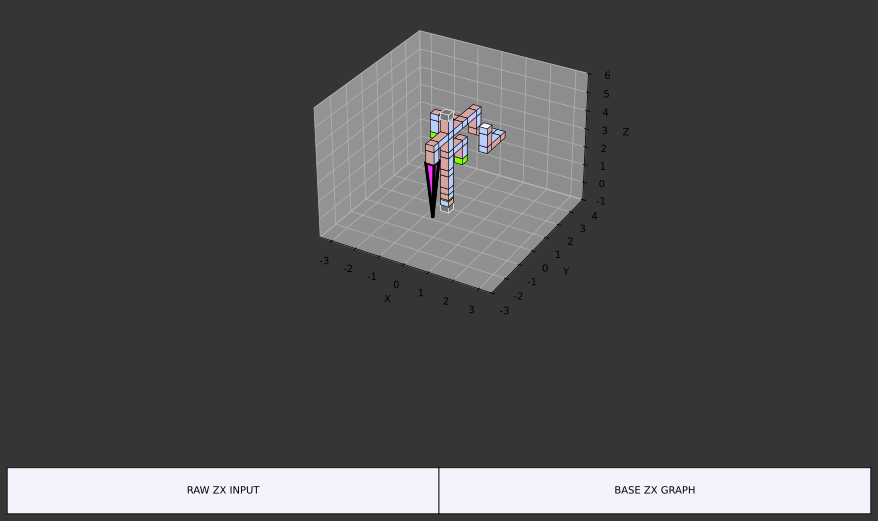

In [5]:
bgraph_manager.draw_blockgraph()

Alternatively, you can also review results by printing the nodes and edges of the `bgraph` attribute of the `BlockGraphManager`.

In [6]:
print("Cubes:")
for n, attrs in bgraph_manager.bgraph.nodes(data=True):
    print(n, attrs)

print("Pipes:")
for u, v, attrs in bgraph_manager.bgraph.edges(data=True):
    print((u, v), attrs)

Cubes:
0 {'zx_block': ZXBlock(zx_type='O', kind='OOO'), 'coords': (0, 0, 0), 'completions': {'degree': 1, 'pending': 0}}
1 {'zx_block': ZXBlock(zx_type='Z', kind='ZXX'), 'coords': (0, 0, 1), 'completions': {'degree': 2, 'pending': 0}}
2 {'zx_block': ZXBlock(zx_type='Z', kind='ZXX'), 'coords': (0, 0, 2), 'completions': {'degree': 2, 'pending': 0}}
3 {'zx_block': ZXBlock(zx_type='Z', kind='ZXX'), 'coords': (0, 0, 3), 'completions': {'degree': 3, 'pending': 0}}
4 {'zx_block': ZXBlock(zx_type='Z', kind='ZXX'), 'coords': (0, 0, 4), 'completions': {'degree': 4, 'pending': 0}}
5 {'zx_block': ZXBlock(zx_type='O', kind='OOO'), 'coords': (0, 0, 5), 'completions': {'degree': 1, 'pending': 0}}
6 {'zx_block': ZXBlock(zx_type='Y', kind='YYO'), 'coords': (0, 1, 2), 'completions': {'degree': 1, 'pending': 0}}
7 {'zx_block': ZXBlock(zx_type='T', kind='TTO'), 'coords': (0, -1, 3), 'completions': {'degree': 1, 'pending': 0}}
9 {'zx_block': ZXBlock(zx_type='X', kind='ZZX'), 'coords': (0, 1, 4), 'completio